# Player Statistics

This notebook trains and serialises a machine learning model to predict the basketball position of a player based on their in-game counting statistics (e.g. points, rebounds, assists etc). The approach taken includes:
* Splitting the data into train/test sets with stratification
* Using cross-validation (CV=4) to get a reliable estimate of model generalisation during model selection
* Keeping the test set completely held out during model selection and hyperparameter tuning
* Comparing multiple models (Logistic Regression, Decision Trees, Random Forest, Histogram Gradient Boosting, SVM) using nested cross-validation
* Using appropriate metrics (balanced_accuracy and f1_macro) for the imbalanced multi-class problem
* Evaluating the final chosen model (SVM) on the held-out test set to get an unbiased estimate of performance
* Retraining the best model (SVM in this case) on the entire dataset (train + test). 

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
from IPython.utils import io
from contextlib import contextmanager
from scipy.stats import uniform, loguniform
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.svm import  SVC
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme()
%matplotlib inline

In [2]:
np.random.seed(0)

## (1) Read in Data


In [3]:
player_statistics = pd.read_csv(os.path.join("data", "api_player_stats.csv"))

## (2) Problem definition

In [4]:
player_statistics['pos'].value_counts()

pos
G    1781
F    1476
C     559
Name: count, dtype: int64

Since most observations are Forward and Guards, this represents an **imbalanced, multi-classs classification problem.** Additionally, False Positive's and False Negative's are equally importance (i.e. we want fair performance predicting across all classes).

As such, we will use appropriate metrics like:

* `balanced_accuracy`,
* `f1_macro`

## (3) Feature Selection

### Preparation of dataset

In [5]:
# separate data
target_name = "pos"
target = player_statistics[target_name]
data = player_statistics.drop(columns=[target_name, "player", "player_id"])

# retrieve column types
numerical_columns_selector = selector(dtype_exclude=object)
numerical_columns = numerical_columns_selector(data)

# define transformers
numerical_preprocessor = StandardScaler()

# define column transformer
preprocessor = ColumnTransformer(
    [
        ("numerical_preprocessing", numerical_preprocessor, numerical_columns)
    ],
    remainder="passthrough"
)

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.25, stratify=target, random_state=42)

# Obtain feature names
feats = data.columns.tolist()

In [7]:
# KBest
def select_kbest_rankings(X_train, y_train, feats):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    select = SelectKBest(k=11)
    select.fit_transform(X_scaled, y_train)
    scores = [(i, score) for i, score in enumerate(select.scores_)]
    sorted_scores = sorted(scores, key=lambda tup: tup[1], reverse=True)
    sorted_scores_feats = [(feats[idx], score) for idx, score in sorted_scores]
    sorted_feats = [feats[i] for i, _ in sorted_scores]
    print("--------------------------------")
    print("KBest Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(sorted_scores_feats, '\n')
    print("Features in order of importance (descending):")
    print(sorted_feats)
    print("--------------------------------")

# Mutual Information Gain
def mutualinfo_rankings(X_train, y_train, feats):
    importances = mutual_info_classif(X_train, y_train)
    df_test = pd.DataFrame({"features": feats, "importances": importances})
    df_sorted = df_test.sort_values('importances', ascending= False)
    print("Mutual Information Gain Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(list(zip(df_sorted.features.to_list(), df_sorted.importances.to_list())), '\n')
    print("Features in order of importance (descending):")
    print(df_sorted.features.to_list())
    print("--------------------------------")

def chi2_rankings(X_train, y_train, feats):
    # Drop 4 negative records
    mask = (X_train >= 0).all(axis=1)
    X_train_clean = X_train[mask]
    y_train_clean = y_train[mask]
    # Run chi2 test
    select = SelectKBest(score_func=chi2, k='all')
    select.fit(X_train_clean, y_train_clean)
    scores = [(feats[i], score) for i, score in enumerate(select.scores_)]
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
    print("Chi2 Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(sorted_scores, '\n')
    print("Features in order of importance (descending):")
    print([f for f, _ in sorted_scores])
    print("--------------------------------")

select_kbest_rankings(X_train, y_train, feats)
mutualinfo_rankings(X_train, y_train, feats)
chi2_rankings(X_train, y_train, feats)

--------------------------------
KBest Feature Selection
--------------------------------
Features with scores:
[('BLK', 560.9086296513454), ('REB', 465.4651890363058), ('AST_TO', 257.69150182073435), ('AST', 167.57672031096845), ('STL', 76.21534049660785), ('STOCKS', 74.7085190399088), ('TOV', 22.307756539974154), ('PTS', 6.522924962199562), ('FIC', 5.9788655559022335), ('year', 1.7228001245782645), ('age', 1.1132622841593616)] 

Features in order of importance (descending):
['BLK', 'REB', 'AST_TO', 'AST', 'STL', 'STOCKS', 'TOV', 'PTS', 'FIC', 'year', 'age']
--------------------------------
Mutual Information Gain Feature Selection
--------------------------------
Features with scores:
[('BLK', 0.1602179759847202), ('AST_TO', 0.13668106302099314), ('REB', 0.12955474436044678), ('AST', 0.08996683642482672), ('TOV', 0.038483873154285586), ('STOCKS', 0.03644539478898601), ('STL', 0.03615917687088688), ('FIC', 0.01315301622332421), ('PTS', 0.00792531804166563), ('year', 0.0051684255456261

Get rid of age and year attributes (consistently part the 3 least important attributes).

In [8]:
# separate data
target_name = "pos"
target_response = player_statistics[target_name]

# encode target response
le = LabelEncoder()
target = le.fit_transform(target_response)

# separate data
data = player_statistics.drop(columns=[target_name, "player", "player_id", "age", "year"])

# retrieve column types
numerical_columns_selector = selector(dtype_exclude=object)
numerical_columns = numerical_columns_selector(data)

# define transformers
numerical_preprocessor = StandardScaler()

# define column transformer
preprocessor = ColumnTransformer(
    [
        ("numerical_preprocessing", numerical_preprocessor, numerical_columns)
    ],
    remainder="passthrough"
)

## (4) Building ML Model

### Defining PlayerStatisticsModel class

In [9]:
class PlayerStatisticsModel:
    """
     This class enables easy the creation and evaluation of different models to predict a players position based
     on their statistics.
    """
    def __init__(self, model, preprocessor: ColumnTransformer, data: pd.DataFrame, target: pd.Series, cv: int):
        """
         Initialisation of PlayerStatisticsModel class.
        
         Inputs:
          - model: sklearn machine learning model class
          - preprocessor (ColumnTransformer): preprocessing steps
          - data: input features
          - target: input target
          - cv: number of cv folds to estimate generalisability of model
        """
        self.metrics = ["balanced_accuracy", "f1_macro"]  # metrics to evaluate/fit models
        self.cv = cv  # number of cv folds
        self.results = pd.DataFrame()   # dataframe to store performance results of models
        self.data = data
        self.target = target
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(data, target, test_size = 0.25, stratify=target, random_state=42)
        self.preprocessor = preprocessor
        self.model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )
    @contextmanager
    def _suppress_warnings_and_output(self):
        # save original warning environment variable
        original_warnings = os.environ.get("PYTHONWARNINGS", "")
        
        # suppress UserWarning and FutureWarning
        os.environ["PYTHONWARNINGS"] = "ignore::UserWarning, ignore::FutureWarning"
        warnings.filterwarnings("ignore", category=UserWarning)
        warnings.filterwarnings("ignore", category=FutureWarning)

        # capture all stdout/stderr output
        with io.capture_output() as captured:
            try:
                yield captured
            finally:
                # restore warnings environment and filters
                os.environ["PYTHONWARNINGS"] = original_warnings
                warnings.filterwarnings("default", category=UserWarning)
                warnings.filterwarnings("default", category=FutureWarning)
    def print_cv_results(self, dict_results:dict[tuple]):
        """
         Prints the mean and standard deviation cross-validation score for a specified metrics in a pretty format.
        
         Inputs:
          - dict_results (dict[tuple]): the mean & std results of a model on all evaluation metrics
        """
        for metric, value in dict_results.items():
            print(f"The mean cross-validation {metric} score is: "
            f"{value[0]:.3f} ± {value[1]:.3f}")
    def plot_fold_comparison(self, metric: str, fold_results: tuple[list[int]], label_names: tuple[str], colors: tuple[str]):
        """
         Plots a comparison of the model's evaluation metric (i.e. performance) on each individual cross-validation
         fold. If there are 4 cross-validation folds, a scatterplot with four dots will be plotted.
        
         Inputs:
          - metric (str): sklearn evaluation metric of choice
          - fold_results (tuple[list[int]]): tuple containing the fold results of each model
          - label_names (tuple[str]): names to give each to each model in the legend of plot
          - colors (tuple[str]): colors to give each model in the plot
        """
        # handle edge case: user passes in invalid metric to plot
        if metric not in self.metrics:
            raise Exception(f"Please pass in a valid metric: {self.metrics}")
        else:
            fig, ax = plt.subplots(figsize=(6, 5))
            # iterate through each model's fold_result, adding scatterplots
            for i in range(len(fold_results)):
                indicies = np.arange(len(fold_results[i][metric]))
                sns.scatterplot(x=indicies, y=fold_results[i][metric], color=f"tab:{colors[i]}", label=label_names[i], ax=ax)
            # plot axis settings
            ax.set_xlabel("Cross-validation iteration")
            ax.set_ylabel("Balanced Accuracy")
            ax.set_title(f"{self.cv}-Fold {metric}")
            ax.set_xticks(np.arange(0, self.cv))
            ax.set_ylim(0,1)
            ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    def _add_model_results(self, model_result: dict[list], model_name: str):
        """
         Anonymous function that concatenates the mean and standard deviation cross-validation score for all
         specified metrics of a model onto a pre-existing dataframe (self.results). This enables us to 
         quickly compare the cv-performance of models as we build them.

         Inputs:
          - model_result (dict[list]): dictionary containing the mean & std results for each model metric
          - model_name (str): name of the model that will exist as its index in the self.results df
        """   
        # Gets model results as df to append to self.results
        df = pd.DataFrame(model_result)
        # extract rows and add suffixes to column names, then combine
        mean_row = df.iloc[0].rename(lambda col: f"{col}_mean")
        std_row = df.iloc[1].rename(lambda col: f"{col}_std")
        flattened_series = pd.concat([mean_row, std_row])
        flattened_df = pd.DataFrame([flattened_series])
        # set the index to the model name
        flattened_df.index = [model_name]
        # if model already exists in results df, then replace. Otherwise, append.
        if model_name in list(self.results.index):
            self.results.loc[model_name] = flattened_df.iloc[0]
        else:
            self.results = pd.concat([self.results, flattened_df])
    def cv_score(self, model_name: str) -> tuple[dict[list], dict[list]]:
        """
         Runs cross-validation on the default model (i.e. without hyperparameter tuning), obtaining the 
         performance of the model.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
        """   
        # get CV scores for default model
        dict_scores_agg = dict()
        dict_scores_folds = dict()
        for metric in self.metrics:
            cv_results = cross_validate(self.model, data, target, cv=self.cv, scoring=metric)
            scoring = cv_results['test_score']
            dict_scores_agg[metric] = (scoring.mean(), scoring.std())
            dict_scores_folds[metric] = scoring
        self._add_model_results(dict_scores_agg, model_name)
        return dict_scores_agg, dict_scores_folds
    def grid_search_cv_score(self, model_name: str, param_grid: dict):
        """
         Fits a model with grid_search to tune its hyperparameters. Then performs nested cross-validation to
         obtain an estimate of the generalisability of the model & variance of this estimate.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
          - param_grid (dict): grid of hyperparameters to iterate through
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
          - best_model: sklearn model of best performing model after gridsearch hyperparameter tuning
        """
        with self._suppress_warnings_and_output():
            model_grid_search = GridSearchCV(self.model, param_grid=param_grid, n_jobs=-1, scoring=self.metrics, refit=self.metrics[0], verbose=1)
            # fit grid search on training data to extract best model
            model_grid_search.fit(self.X_train, self.y_train)
            best_model = model_grid_search.best_estimator_
            # get nested CV scores for best model
            dict_scores_agg = dict()
            dict_scores_folds = dict()
            # perform nested cv for each metric, storing results in dictionaries
            for metric in self.metrics:
                cv_results = cross_validate(model_grid_search, data, target, cv=self.cv, n_jobs=-1, scoring=metric)
                scoring = cv_results['test_score']
                dict_scores_agg[metric] = (scoring.mean(), scoring.std())
                dict_scores_folds[metric] = scoring
            # add results to dataframe for easy model comparison
            self._add_model_results(dict_scores_agg, model_name)
            return dict_scores_agg, dict_scores_folds, best_model
    def randomised_search_cv_score(self, model_name: str, param_distributions: dict, n_iter: int):
        """
         Fits a model with randomised_search to tune its hyperparameters. Then performs nested cross-validation to
         obtain an estimate of the generalisability of the model & variance of this estimate.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
          - param_distributions (dict): range of possible values each hyperparameter that can be sampled
          - n_iter (int): number of iterations to run randomised_search (i.e. models to be fitted & evaluated)
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
          - best_model: sklearn model of best performing model after gridsearch hyperparameter tuning
        """
        with self._suppress_warnings_and_output():
            model_random_search = RandomizedSearchCV(self.model, param_distributions=param_distributions, n_iter=n_iter, n_jobs=-1, scoring=self.metrics, refit=self.metrics[0], verbose=1)
            # fit grid search on training data to extract best model
            model_random_search.fit(self.X_train, self.y_train)
            best_model = model_random_search.best_estimator_
            # get nested CV scores for best model
            dict_scores_agg = dict()
            dict_scores_folds = dict()
            # perform nested cv for each metric, storing results in dictionaries
            for metric in self.metrics:
                cv_results = cross_validate(model_random_search, data, target, cv=self.cv, n_jobs=-1, scoring=metric)
                scoring = cv_results['test_score']
                dict_scores_agg[metric] = (scoring.mean(), scoring.std())
                dict_scores_folds[metric] = scoring
            # add results to dataframe for easy model comparison    
            self._add_model_results(dict_scores_agg, model_name)
            return dict_scores_agg, dict_scores_folds, best_model
    def get_best_tuned_params(self, best_model, param_grid: dict):
        """
         Gets the best tuned parameters for a model after gridsearch or randomised_search hyperparameter tuning.

         Inputs:
          - best_model: sklearn model of best performing model after hyperparameter tuning
          - param_grid (dict): grid of hyperparameters to iterate through
         
         Returns:
          - dictionary of tuned parameters and their values for the best model
        """
        params = [param for param in best_model.get_params() if param.startswith('model__') and param in list(param_grid.keys())]
        params_values = [best_model.get_params()[param] for param in params]
        return dict(zip(params, params_values))

### XGBoost - Extreme Gradient Boosting

The following uses the XGBoost Scikit-Learn Wrapper.

* For multiclass boosting, the proper loss is multiclass cross-entropy.

* In XGBoost: objective=`"multi:softprob"`
* This loss is differentiable and produces calibrated class probabilities, which boosting requires.
* Balanced accuracy is a non-differentiable evaluation metric, so it cannot be optimized directly. **Training minimizes log-loss, evaluation selects the model via balanced accuracy.**
* With moderate imbalance (e.g., 559 / 1476 / 1781), weighting helps prevent majority-class dominance.
* Let's continue with Optuna + XGBoost (3 classes) + balanced accuracy, with a 25% test set kept fully untouched until the end.

In [46]:
import xgboost as xgb
import optuna
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score
import plotly # Required for Optuna visualizations

# Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.25, stratify=target, random_state=42)

In [48]:
num_classes = 3   ## three target classes

# compute class weights once, from the training labels
# e.g. {0: 2.1, 1: 0.8, 2: 0.7}
classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight="balanced",
                                           classes=classes,
                                           y=y_train)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights_array)}


def objective(trial):
    """
      Optuna objective: tune multiclass XGBoost using CV, maximise Balanced Accuracy.
    """
    ### Define hyperparameters to tune using trial.suggest_... methods
    trial_params = {
      ## Tuned hyperparameters - reasonable ranges
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),  # step size
      'max_depth': trial.suggest_int('max_depth', 3, 10),  # max depth of individual trees
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),  # % of dataset for each tree
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),  # % of features for each tree
      'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),  # L2 reg
      'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),    # L1 reg
      'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),  # min loss for split
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # min sum instance weight in child
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000)  # number of boosting rounds/trees
    }
    
    ### Define base model
    model = xgb.XGBClassifier(
      ## Fixed hyperparameters
      objective = 'multi:softprob',   # multiclass probabilities
      num_classes = num_classes,
      eval_metric = 'mlogloss',    # differentiable multiclass metric for training
      njobs = -1,
      random_state = 42,
      use_label_encoder = False,
      **trial_params
    )

    # cv on training set, with each fold preserving class proportions
    cv = StratifiedKFold(
      n_splits = 4,
      shuffle = True,  # randomise split instead of contguous chunks
      random_state = 42
    )
    
    # stores balanced_accuracy cv scores
    cv_scores = []
    
    # divide training set into rows for training & validation each iteration
    # run 4 times, each loop training a new XGBoost on 75% train, and evaluates on 25% eval
    for train_idx, val_idx in cv.split(X_train, y_train):
      # X_train, y_train are pandas → use iloc for row-wise indexing
      X_tr = X_train.iloc[train_idx] if hasattr(X_train, "iloc") else X_train[train_idx]
      X_val = X_train.iloc[val_idx] if hasattr(X_train, "iloc") else X_train[val_idx]
      y_tr = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
      y_val = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]

      # convert class weights to sample weights for training labels in only this fold
      if hasattr(y_tr, "map"):
        sample_weight_tr = y_tr.map(class_weight_dict).to_numpy()
      else:
        sample_weight_tr = np.array([class_weight_dict[c] for c in y_tr])

      # For early stopping, we give a large n_estimators and let it cut back
      model.set_params(early_stopping_rounds=50)

      model.fit(
          X_tr,
          y_tr,
          sample_weight = sample_weight_tr,
          eval_set=[(X_tr, y_tr), (X_val, y_val)],
          verbose=False
      )

      # compute and store balanced accuracy in cv_scores list
      y_val_pred = model.predict(X_val)
      ba = balanced_accuracy_score(y_val, y_val_pred)
      cv_scores.append(ba)
    return np.mean(cv_scores)  # Optuna maximises this - mean bal_accuracy from 4-cv folds (single optuna trial)

* Only X_train, y_train are used in model training.

* Balanced accuracy is computed on each fold’s validation set.  

* Optuna maximises mean CV balanced accuracy.


In [49]:
## Run Optuna Study (still only on train)
study = optuna.create_study(
    direction = "maximize",    # goal: maximise cv bal acccuracy score (returned value)
    study_name = 'xgb_multiclass_bal_accuracy'
)

study.optimize(objective, n_trials=50, show_progress_bar=True)  # run study 50 times finding diff. hyperparameter sets

[I 2026-01-24 11:34:42,480] A new study created in memory with name: xgb_multiclass_bal_accuracy
  0%|          | 0/50 [00:00<?, ?it/s]/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encode

[I 2026-01-24 11:34:47,610] Trial 0 finished with value: 0.7572651897193032 and parameters: {'learning_rate': 0.04571041542937559, 'max_depth': 7, 'subsample': 0.5845305732019908, 'colsample_bytree': 0.5946369954296147, 'lambda': 0.00024878071032505256, 'alpha': 4.483286814324603e-05, 'gamma': 3.4837977726154294, 'min_child_weight': 10, 'n_estimators': 896}. Best is trial 0 with value: 0.7572651897193032.


/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 1. Best value: 0.762192:   4%|▍         | 2/50 [00:0

[I 2026-01-24 11:34:51,657] Trial 1 finished with value: 0.7621924980026211 and parameters: {'learning_rate': 0.04017809272605898, 'max_depth': 9, 'subsample': 0.6245533121280105, 'colsample_bytree': 0.6287944386249582, 'lambda': 1.387818044878131e-08, 'alpha': 1.0966024314357007e-07, 'gamma': 0.00028398012536724705, 'min_child_weight': 10, 'n_estimators': 128}. Best is trial 1 with value: 0.7621924980026211.


/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:34:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 1. Best value: 0.762192:   6%|▌         | 3/50 [00:1

...

[I 2026-01-24 11:41:49,564] Trial 47 finished with value: 0.7615753790670868 and parameters: {'learning_rate': 0.015588933543202716, 'max_depth': 5, 'subsample': 0.626128580260775, 'colsample_bytree': 0.9873451427475892, 'lambda': 0.006696343070419665, 'alpha': 0.0002987418739031047, 'gamma': 0.20634049257553375, 'min_child_weight': 2, 'n_estimators': 989}. Best is trial 41 with value: 0.7703998469403932.


/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:41:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:41:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:41:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 41. Best value: 0.7704:  98%|█████████▊| 49/50 [07:1

[I 2026-01-24 11:41:57,366] Trial 48 finished with value: 0.764166452754731 and parameters: {'learning_rate': 0.022265813488518034, 'max_depth': 6, 'subsample': 0.5872646389696561, 'colsample_bytree': 0.9519718675681365, 'lambda': 0.027975215138285082, 'alpha': 0.00014268105661294835, 'gamma': 0.020204714229691195, 'min_child_weight': 3, 'n_estimators': 646}. Best is trial 41 with value: 0.7703998469403932.


/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:42:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:42:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:42:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 41. Best value: 0.7704: 100%|██████████| 50/50 [07:2

[I 2026-01-24 11:42:07,572] Trial 49 finished with value: 0.7645713493288043 and parameters: {'learning_rate': 0.011298573597084102, 'max_depth': 4, 'subsample': 0.5003398187815968, 'colsample_bytree': 0.6096839063426894, 'lambda': 0.00018246571603059388, 'alpha': 2.0111940654471217e-05, 'gamma': 1.2931230671025968, 'min_child_weight': 4, 'n_estimators': 714}. Best is trial 41 with value: 0.7703998469403932.


In [50]:
print("Best trial BA:", study.best_value)
print("Best params:", study.best_params)

Best trial BA: 0.7703998469403932
Best params: {'learning_rate': 0.012266724422776293, 'max_depth': 5, 'subsample': 0.5404225956945117, 'colsample_bytree': 0.949610143376611, 'lambda': 0.0033618710802738394, 'alpha': 0.00019472731613421034, 'gamma': 5.644330244530672e-08, 'min_child_weight': 4, 'n_estimators': 882}


* The best Optuna trial returned with a Balanced Accuracy of 74.51%. 
* We will compare this with other models.

### CatBoost

In [51]:
import optuna
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
import numpy as np

num_classes = 3

# compute class weights from training labels
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Map class → weight, e.g. {0: 2.9, 1: 1.1, 2: 0.9}
class_weight_dict = dict(zip(classes, class_weights_array))

# CatBoost wants a list of weights in class-index order
# assuming your classes are 0,1,2 this preserves order
catboost_class_weights = [class_weight_dict[c] for c in classes]
def objective_cat(trial):
    """
    Optuna objective: tune multiclass CatBoost using CV, 
    maximise Balanced Accuracy, with class imbalance handled via class_weights.
    """

    # ---- hyperparameters to tune 
    trial_params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),       # total boosting iterations
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 10),                     # tree depth
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 0.5, 10.0)
    }

    # ---- base CatBoost model ----
    model = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="MultiClass",        # internal training metric
        random_seed=42,
        thread_count=-1,
        class_weights=catboost_class_weights,  # <-- handles class imbalance
        verbose=False,
        **trial_params
    )

    # ---- 4-fold stratified CV on training set ----
    cv = StratifiedKFold(
        n_splits=4,
        shuffle=True,
        random_state=42
    )

    cv_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        # subset rows for this fold
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # fit on this fold (CatBoost handles early stopping via iterations + overfitting detector internally if tuned)
        model.fit(
            X_tr,
            y_tr,
            eval_set=(X_val, y_val),
            verbose=False
        )

        # evaluate on validation fold
        y_val_pred = model.predict(X_val)
        ba = balanced_accuracy_score(y_val, y_val_pred)
        cv_scores.append(ba)

    # Optuna maximises mean balanced accuracy across folds
    return np.mean(cv_scores)

In [52]:
## Run Optuna Study (still only on train)
study = optuna.create_study(
    direction = "maximize",    # goal: maximise cv bal acccuracy score (returned value)
    study_name = 'catboost_multiclass_bal_accuracy'
)

study.optimize(objective, n_trials=50, show_progress_bar=True)  # run study 50 times finding diff. hyperparameter sets

[I 2026-01-24 11:56:05,532] A new study created in memory with name: catboost_multiclass_bal_accuracy
  0%|          | 0/50 [00:00<?, ?it/s]/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_e

[I 2026-01-24 11:56:14,817] Trial 0 finished with value: 0.760865522129893 and parameters: {'learning_rate': 0.03292808684722965, 'max_depth': 4, 'subsample': 0.9946680489439996, 'colsample_bytree': 0.7736252248398501, 'lambda': 0.01732557671747556, 'alpha': 0.019157645230505543, 'gamma': 2.791259923883104e-08, 'min_child_weight': 10, 'n_estimators': 980}. Best is trial 0 with value: 0.760865522129893.


/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 0. Best value: 0.760866:   4%|▍         | 2/50 [00:2

[I 2026-01-24 11:56:28,733] Trial 1 finished with value: 0.7527362588021407 and parameters: {'learning_rate': 0.022484335393939386, 'max_depth': 9, 'subsample': 0.6829077795939793, 'colsample_bytree': 0.6005747574871685, 'lambda': 0.061956590841165976, 'alpha': 0.10391117698995017, 'gamma': 0.03095734196967628, 'min_child_weight': 1, 'n_estimators': 460}. Best is trial 0 with value: 0.760865522129893.


/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [11:56:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 0. Best value: 0.760866:   6%|▌         | 3/50 [00:2

...

[I 2026-01-24 12:00:47,137] Trial 47 finished with value: 0.7575575893710638 and parameters: {'learning_rate': 0.031131870253428662, 'max_depth': 3, 'subsample': 0.6533799628574521, 'colsample_bytree': 0.8428895482317438, 'lambda': 1.0309825245274191, 'alpha': 6.507877750879804e-08, 'gamma': 0.00010710251129367757, 'min_child_weight': 3, 'n_estimators': 262}. Best is trial 25 with value: 0.7690136112041732.


/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [12:00:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [12:00:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [12:00:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 25. Best value: 0.769014:  98%|█████████▊| 49/50 [04

[I 2026-01-24 12:00:54,938] Trial 48 finished with value: 0.7611088208810085 and parameters: {'learning_rate': 0.022150624553728963, 'max_depth': 5, 'subsample': 0.5983338424599126, 'colsample_bytree': 0.6939071516597441, 'lambda': 0.0395604903879188, 'alpha': 6.797151069884877e-06, 'gamma': 0.000808332811351178, 'min_child_weight': 4, 'n_estimators': 569}. Best is trial 25 with value: 0.7690136112041732.


/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [12:00:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [12:00:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [12:01:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "njobs", "num_classes", "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 25. Best value: 0.769014: 100%|██████████| 50/50 [04

[I 2026-01-24 12:01:04,385] Trial 49 finished with value: 0.7605576660751882 and parameters: {'learning_rate': 0.02788885749358508, 'max_depth': 6, 'subsample': 0.716140336157388, 'colsample_bytree': 0.8008373882625832, 'lambda': 1.795781273226981e-05, 'alpha': 3.0439227881332987e-07, 'gamma': 7.199196213003529e-06, 'min_child_weight': 1, 'n_estimators': 409}. Best is trial 25 with value: 0.7690136112041732.


In [53]:
print("Best trial BA:", study.best_value)
print("Best params:", study.best_params)

Best trial BA: 0.7690136112041732
Best params: {'learning_rate': 0.025578980744535833, 'max_depth': 5, 'subsample': 0.6391298692347247, 'colsample_bytree': 0.7318049231655674, 'lambda': 5.336434010250195e-05, 'alpha': 1.0700780880539812e-08, 'gamma': 4.551202681205232e-05, 'min_child_weight': 3, 'n_estimators': 195}


### LightGBM

In [ ]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, f1_score

num_classes = 3  # three target classes

# ---- compute class weights from training labels ----
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights_array))
# e.g. {0: 2.9, 1: 1.1, 2: 0.9}

def objective_lgb(trial):
    """
    Optuna objective: tune multiclass LightGBM using CV, maximise Balanced Accuracy,
    with class imbalance handled via class_weight.
    """

    # ---- hyperparameters to tune ----
    trial_params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", -1, 12),                # -1 = no limit
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),            # row subsampling
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # feature subsampling
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),  # L2
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),    # L1
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000)
    }

    # ---- base LightGBM model ----
    model = lgb.LGBMClassifier(
        objective="multiclass",
        num_class=num_classes,
        class_weight=class_weight_dict,   # handles class imbalance
        random_state=42,
        n_jobs=-1,
        **trial_params
    )

    # ---- stratified 4-fold CV on training set ----
    cv = StratifiedKFold(
        n_splits=4,
        shuffle=True,
        random_state=42
    )

    cv_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        # robust indexing for pandas / numpy
        if hasattr(X_train, "iloc"):
            X_tr = X_train.iloc[train_idx]
            X_val = X_train.iloc[val_idx]
        else:
            X_tr = X_train[train_idx]
            X_val = X_train[val_idx]

        if hasattr(y_train, "iloc"):
            y_tr = y_train.iloc[train_idx]
            y_val = y_train.iloc[val_idx]
        else:
            y_tr = y_train[train_idx]
            y_val = y_train[val_idx]

        # ---- early stopping via callbacks ----
        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)  # turn off per-iteration logging
        ]

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="multi_logloss",
            callbacks=callbacks,      # <--- instead of early_stopping_rounds=
        )

        # evaluate fold
        y_val_pred = model.predict(X_val)
        ba = balanced_accuracy_score(y_val, y_val_pred)
        cv_scores.append(ba)

    # Optuna maximises mean balanced accuracy across folds
    return np.mean(cv_scores)

In [ ]:
# ---- Run Optuna Study for LightGBM ----
import optuna

study_lgb = optuna.create_study(
    direction="maximize",
    study_name="lgbm_multiclass_balanced_accuracy"
)
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

[I 2026-01-24 12:04:35,517] A new study created in memory with name: lgbm_multiclass_balanced_accuracy
  0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2106
[LightGBM] [Info] Number of data points in the train set: 2146, number of used features: 9
[LightGBM] [Info] Start training from score -1.099043
[LightGBM] [Info] Start training from score -1.098548
[LightGBM] [Info] Start training from score -1.098247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

Best trial: 0. Best value: 0.761218:   2%|▏         | 1/50 [00:11<09:02, 11.07s/it]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

Best trial: 0. Best value: 0.761218:   4%|▍         | 2/50 [00:27<11:28, 14.34s/it]

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

Best trial: 21. Best value: 0.762886:  46%|████▌     | 23/50 [04:40<08:53, 19.76s/it]

[I 2026-01-24 12:09:15,988] Trial 22 finished with value: 0.7610060987037512 and parameters: {'learning_rate': 0.010755787110371768, 'max_depth': 7, 'num_leaves': 161, 'min_child_samples': 59, 'subsample': 0.9932072336209464, 'colsample_bytree': 0.6688607513567058, 'reg_lambda': 0.083951823923124, 'reg_alpha': 0.5590546339727764, 'n_estimators': 917}. Best is trial 21 with value: 0.7628855510060062.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2106
[LightGBM] [Info] Number of data points in the train set: 2146, number of used features: 9
[LightGBM] [Info] Start training from score -1.099043
[LightGBM] [Info] Start training from score -1.098548
[LightGBM] [Info] Start training from score -1.098247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

Best trial: 21. Best value: 0.762886:  48%|████▊     | 24/50 [04:59<08:29, 19.61s/it]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [ ]:
print("Best trial BA:", study.best_value)
print("Best params:", study.best_params)

### Linear model - Logistic Regression

#### Estimating generalisability of untuned Logistic Regression model

In [14]:
psm_log = PlayerStatisticsModel(LogisticRegression(random_state=42), preprocessor, data, target, cv=4)
log_cv_score_agg, log_cv_score = psm_log.cv_score(model_name='base_log_reg')
psm_log.print_cv_results(log_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.704 ± 0.034
The mean cross-validation f1_macro score is: 0.712 ± 0.023


#### Estimating generalisability of tuned Logistic Regression model with GridSearchCV

In [15]:
param_grid = {
    'model__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['saga'],
    'model__l1_ratio': [0, 0.5, 1],
    'model__class_weight': [None, 'balanced']
}

log_gridsearch_cv_score_agg, log_gridsearch_cv_score, log_gridsearch_model = psm_log.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_log_reg')

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits


KeyboardInterrupt: 

In [13]:
psm_log.print_cv_results(log_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.740 ± 0.025
The mean cross-validation f1_macro score is: 0.715 ± 0.014


* We observe a significant improvement in balanced_accuracy with GridSearchCV, and a slight improvement in f1_macro. Overall, the model performs better.  

* However, there may exist unimportant parameters we tuned. We can turn to RandomisedSearchCV aswell.

#### Estimating generalisability of tuned Logistic Regression model with RandomizedSearchCV

In [14]:
param_dist = {
    'model__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'model__C': loguniform(1e-3, 1e3),    # continuous sampling over [0.001, 1000]
    'model__solver': ['saga'],
    'model__l1_ratio': uniform(0, 1),    # continuous over [0,1]
    'model__class_weight': [None, 'balanced']
}

log_randomsearch_cv_score_agg, log_randomsearch_cv_score, log_randomsearch_model = psm_log.randomised_search_cv_score(param_distributions=param_dist, n_iter=50, model_name='randomsearch_log_reg')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [15]:
psm_log.print_cv_results(log_randomsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.741 ± 0.020
The mean cross-validation f1_macro score is: 0.714 ± 0.014


In [16]:
psm_log.results

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.740515,0.714428,0.019932,0.013582


**Which is the better linear model (tuned w/ GridSearchCV or RandomisedSearchCV)?**

* We observe almost identical performance and variance in balanced_accuracy and f1_macro between the two models. However, the computational performance significantly improves with RandomisedSearchCV - which is important when we extend our dataset size.

* Another way of comparing performance is by counting the number of folds each model performs better in.

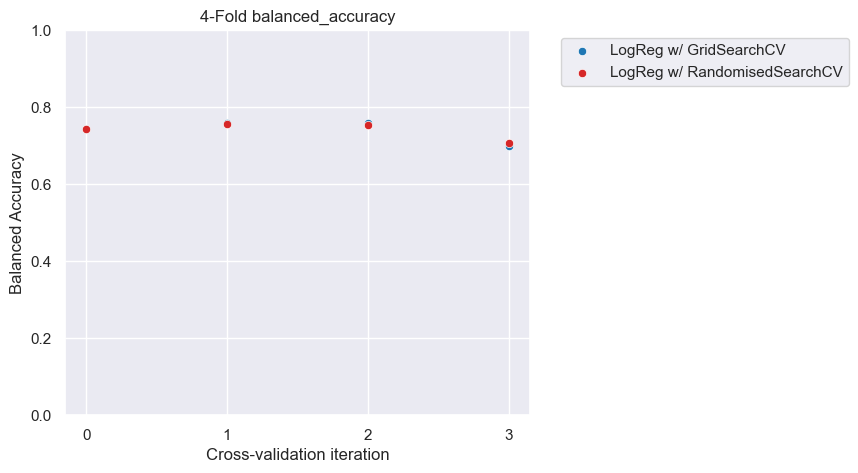

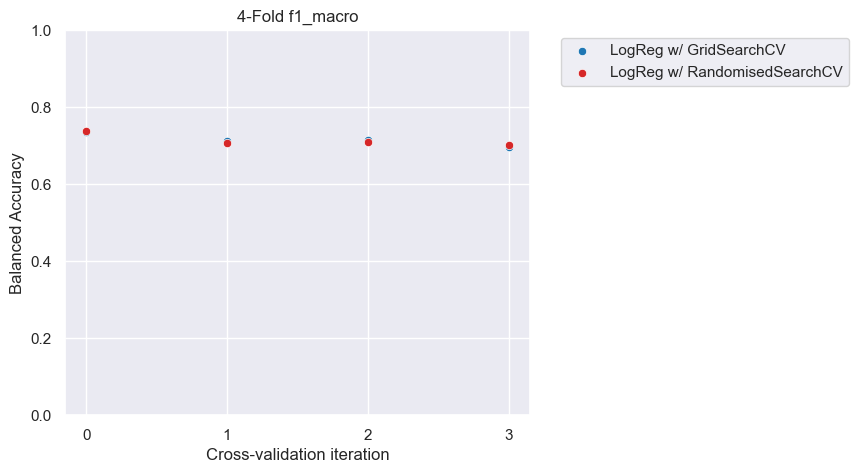

In [17]:
# plotting results from cv-folds for gridsearch and randomisedsearch logistic regression models
fold_results = (log_gridsearch_cv_score, log_randomsearch_cv_score)
label_names = ('LogReg w/ GridSearchCV', 'LogReg w/ RandomisedSearchCV')
colors=('blue', 'red')
psm_log.plot_fold_comparison(metric=psm_log.metrics[0], fold_results=fold_results, label_names=label_names, colors=colors)
psm_log.plot_fold_comparison(metric=psm_log.metrics[1], fold_results=fold_results, label_names=label_names, colors=colors)

**Which is the better linear model (tuned w/ GridSearchCV or RandomisedSearchCV)?**

* We have further proof that there is little separating the linear models tuned with GridSearchCV and RandomisedSearchCV. For all the folds, GridSearchCV performs similarly to RandomisedSearchCV for both the bal_accuracy and f1_macro metrics.

* Therefore, I will be proceeding with the RandomisedSearchCV tuned model since it is ~ 2.5x quicker.

### Tree Model - Decision Tree

#### Estimating generalisability of untuned Logistic Regression model

In [18]:
psm_tree = PlayerStatisticsModel(DecisionTreeClassifier(random_state=42), preprocessor, data, target, cv=4)
tree_cv_score_agg, tree_cv_score = psm_tree.cv_score(model_name='base_tree')
psm_tree.print_cv_results(tree_cv_score)

The mean cross-validation balanced_accuracy score is: 0.648 ± 0.640
The mean cross-validation f1_macro score is: 0.655 ± 0.646


In [19]:
# compare results
pd.concat([psm_log.results, psm_tree.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.740515,0.714428,0.019932,0.013582
base_tree,0.640646,0.647209,0.010807,0.010064


* We observe the Tree has significantly worse performance in both balanced_accuracy and in f1_macro compared to all linear models. Perhaps the data is linearly separable, or the model is significantly overfitting. We need to make it simpler.

* There are a few options we can take. Mainly, specifying a `max_depth` that controls the complexity of the tree (i.e. underfitting/overfitting). Specifying `min_samples_split`, `max_leaf_nodes`, and `min_samples_leaf` enables an asymmetric tree.

#### Estimating generalisability of tuned Tree model varying Max Depth

In [20]:
param_grid = {"model__max_depth": np.arange(2, 16, 1)}

tree_gridsearch_cv_score_agg, tree_gridsearch_cv_score, tree_gridsearch_model = psm_tree.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_tree')

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits


In [21]:
psm_tree.print_cv_results(tree_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.653 ± 0.029
The mean cross-validation f1_macro score is: 0.668 ± 0.025


In [22]:
# optimal max_depth
[value for param, value in tree_gridsearch_model.get_params().items() if param == 'model__max_depth']

[6]

* We observe there is a significant improvement in the model after making it simpler. However, it still underperforms relative to the linear models. Can we further improve performance by adjusting other hyperparameters to allow the tree to be asynmmetric?

#### Estimating generalisability of tuned Tree model with GridSearchCV

In [23]:
param_grid = {"model__max_depth": [9],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
                "model__max_leaf_nodes": [None, 10, 20, 50]}

tree_all_gridsearch_cv_score_agg, tree_all_gridsearch_cv_score, tree_all_gridsearch_model = psm_tree.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_tree_all')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [24]:
psm_tree.print_cv_results(tree_all_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.666 ± 0.029
The mean cross-validation f1_macro score is: 0.680 ± 0.031


In [25]:
# compare results
pd.concat([psm_log.results, psm_tree.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.740515,0.714428,0.019932,0.013582
base_tree,0.640646,0.647209,0.010807,0.010064
gridsearch_tree,0.652721,0.667870,0.029310,0.025352
gridsearch_tree_all,0.665854,0.679741,0.028912,0.031168


* We observe a slight improvement in both `balanced_accuracy` and `f1_macro` after allowing for the creation of an asymmetric tree. However, the model still performs poorly compared to the linear models.

* We can further compare the folds between the best linear model (logistic regression with randomsearch) and best tree (asymmetric decision tree).

### Comparison of folds between best Logistic Regression & Decision Tree models

So far, is the best Logistic Regression Model (LogReg w/ RandomisedSearchCV) or best Tree Model (Asymmetric Tuned Tree) better?

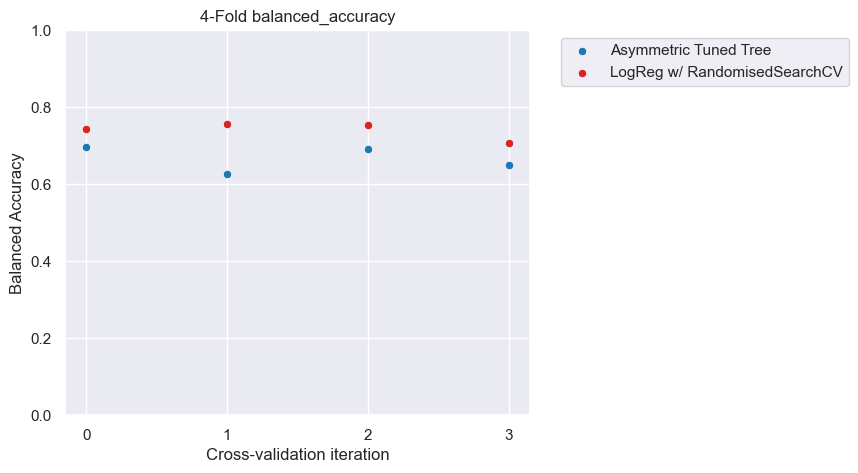

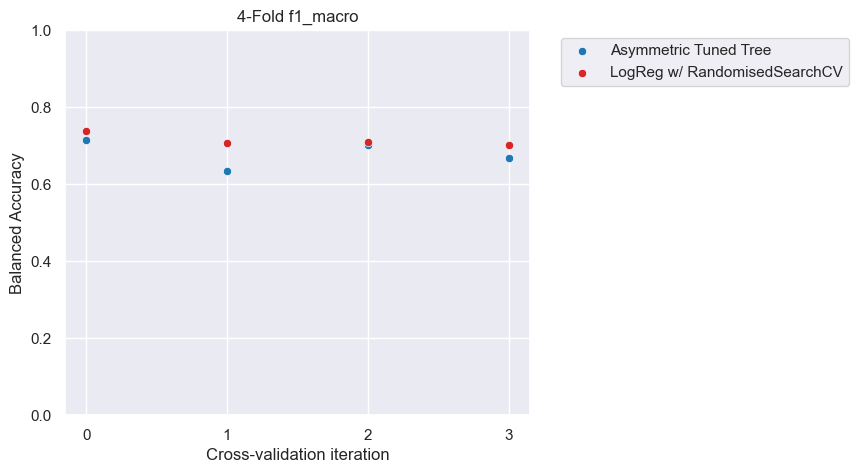

In [26]:
# plotting results from cv-folds for gridsearch and randomisedsearch logistic regression models
fold_results = (tree_all_gridsearch_cv_score, log_randomsearch_cv_score)
label_names = ('Asymmetric Tuned Tree', 'LogReg w/ RandomisedSearchCV')
colors=('blue', 'red')
psm_tree.plot_fold_comparison(metric=psm_tree.metrics[0], fold_results=fold_results, label_names=label_names, colors=colors)
psm_tree.plot_fold_comparison(metric=psm_tree.metrics[1], fold_results=fold_results, label_names=label_names, colors=colors)

* Emphatically, the best model is still logistic regression tuned with randomsearch as all 4 folds perform better in both the `balanced_accuracy` and `f1_macro` metrics.

### Ensemble Models - Random Forest

#### Estimating generalisability of untuned Random Forest

In [27]:
psm_rf = PlayerStatisticsModel(RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1), preprocessor, data, target, cv=4)
rf_cv_score_agg, rf_cv_score = psm_rf.cv_score(model_name='base_rf')
psm_rf.print_cv_results(rf_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.708 ± 0.048
The mean cross-validation f1_macro score is: 0.719 ± 0.036


* Even after hyperparameter tuning, the default Random Forest appeared to perform best. Furthermore, Random Forests are highly computational inefficient. Might Histogram-Based Gradient Boosting (more efficient on larger datasets) perform better?

In [28]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.740515,0.714428,0.019932,0.013582
base_tree,0.640646,0.647209,0.010807,0.010064
gridsearch_tree,0.652721,0.667870,0.029310,0.025352
gridsearch_tree_all,0.665854,0.679741,0.028912,0.031168
base_rf,0.708393,0.718568,0.047660,0.036383


### Ensemble Models - Histogram Gradient Boosting

In [29]:
psm_hbdc = PlayerStatisticsModel(HistGradientBoostingClassifier(max_iter=1000, early_stopping=True, random_state=42, class_weight='balanced'), preprocessor, data, target, cv=4)
hbdc_cv_score_agg, hbdc_cv_score = psm_hbdc.cv_score(model_name='base_hbdc')
psm_hbdc.print_cv_results(hbdc_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.722 ± 0.028
The mean cross-validation f1_macro score is: 0.714 ± 0.023


#### Estimating generalisability of tuned HBDC model with GridSearchCV

In [30]:
param_grid = {
    "model__max_depth": [3, 5, 8],
    "model__max_leaf_nodes": [15, 31],
    "model__learning_rate": [0.05, 0.01, 0.1, 0.2],
    "model__class_weight": ['balanced'],
    "model__early_stopping": [True]
}

hbdc_gridsearch_cv_score_agg, hbdc_gridsearch_cv_score, hbdc_gridsearch_model = psm_hbdc.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_hbdc')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [31]:
psm_hbdc.print_cv_results(hbdc_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.735 ± 0.027
The mean cross-validation f1_macro score is: 0.719 ± 0.014


In [32]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results, psm_hbdc.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.740515,0.714428,0.019932,0.013582
base_tree,0.640646,0.647209,0.010807,0.010064
gridsearch_tree,0.652721,0.667870,0.029310,0.025352
gridsearch_tree_all,0.665854,0.679741,0.028912,0.031168
base_rf,0.708393,0.718568,0.047660,0.036383
base_hbdc,0.721961,0.713665,0.027555,0.023174
gridsearch_hbdc,0.734967,0.718616,0.026959,0.013617


* While we observe a 2% increase in balanced accuracy and 1% increase in f1_macro via gridserch, the Histogram Gradient Boosting model still performs worse compared to the Random Search Logistic Regression model.

### SVM - Non-linear Kernel

In [33]:
psm_svm = PlayerStatisticsModel(SVC(random_state=42), preprocessor, data, target, cv=4)
svm_cv_score_agg, svm_cv_score = psm_svm.cv_score(model_name='linearsvc')
psm_svm.print_cv_results(svm_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.735 ± 0.044
The mean cross-validation f1_macro score is: 0.741 ± 0.030


In [34]:
param_grid = {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.01, 0.001],
        "model__class_weight": ["balanced"],
        "model__probability": [True]      # necessary for prediction probabilities in-app
    }

svm_gridsearch_cv_score_agg, svm_gridsearch_cv_score, svm_gridsearch_model = psm_svm.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_svm')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [35]:
psm_svm.print_cv_results(svm_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.765 ± 0.015
The mean cross-validation f1_macro score is: 0.737 ± 0.014


In [36]:
psm_svm.get_best_tuned_params(svm_gridsearch_model, param_grid)

{'model__C': 10,
 'model__class_weight': 'balanced',
 'model__gamma': 'scale',
 'model__kernel': 'rbf',
 'model__probability': True}

### Final model results comparison

In [37]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results, psm_hbdc.results, psm_svm.results]).sort_values(by=['balanced_accuracy_mean', 'f1_macro_mean'], ascending=False)

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
gridsearch_svm,0.764991,0.736670,0.014688,0.014449
randomsearch_log_reg,0.740515,0.714428,0.019932,0.013582
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
gridsearch_hbdc,0.734967,0.718616,0.026959,0.013617
linearsvc,0.734719,0.740607,0.043883,0.030214
base_hbdc,0.721961,0.713665,0.027555,0.023174
base_rf,0.708393,0.718568,0.047660,0.036383
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_tree_all,0.665854,0.679741,0.028912,0.031168
gridsearch_tree,0.652721,0.667870,0.029310,0.025352


Since the **Grid Search SVM model peformed best** on both the balanced accuracy and f1_macro metrics. It had a balanced accuracy of **76.50%**. We will serialise this model.

## (5) Retrain Best Performing Model on Entire Dataset

Finally, I will retrain the model on the full dataset (training & validation sets) to help the model learn from as much data as possible.

In [49]:
best_model_params = svm_gridsearch_model.get_params()
best_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier())
])
best_model.set_params(**best_model_params)
best_model.fit(data, target)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical_preprocessing',
                                                  StandardScaler(),
                                                  ['PTS', 'AST', 'REB', 'STL',
                                                   'BLK', 'TOV', 'AST_TO',
                                                   'STOCKS', 'FIC'])])),
                ('model',
                 SVC(C=10, class_weight='balanced', probability=True,
                     random_state=42))])

In [53]:
# Export model
## pickle.dump(best_model, open(os.path.join("models", "stats_model.sav"), "wb"))
## pickle.dump(le, open(os.path.join("models", "stats_encoder.sav"), "wb"))

# (6) Test on Dummy Inputs

In [54]:
data.head()

,PTS,AST,REB,STL,BLK,TOV,AST_TO,STOCKS,FIC
0,2.50,0.38,1.12,0.04,0.08,0.08,4.750000,0.12,4.04
1,6.40,0.89,2.55,0.36,0.26,0.38,2.342105,0.62,10.08
2,9.01,1.04,3.49,0.51,0.32,0.41,2.536585,0.83,13.96
3,7.82,1.04,2.21,0.28,0.10,0.60,1.733333,0.38,10.85
4,7.38,0.88,4.05,0.41,0.86,0.83,1.060241,1.27,12.75


In [55]:
def load_model(model):
    return pickle.load(open(model, 'rb'))

stats_predictor = load_model(os.path.join("models", "stats_model.sav"))
stats_le = load_model(os.path.join("models", "stats_encoder.sav"))

# Example inputs
pts, ast, reb, stl, blk, tov = 20, 10, 2, 1, 1, 5
ast_to, stocks, fic = round(ast/tov, 2), round(stl+blk, 2), round(pts+reb+ast+stl+blk-tov, 2)
input_features = pd.DataFrame([[pts, ast, reb, stl, blk, tov, ast_to, stocks, fic]], 
                            columns=['PTS', 'AST', 'REB', 'STL', 'BLK', 'TOV', 'AST_TO', 'STOCKS', 'FIC'])
stats_predictor.predict(input_features)
predicted_pos = stats_le.inverse_transform(stats_predictor.predict(input_features))[0][0]   # obtain prediction using models
print(predicted_pos)

# The pipeline will handle the scaling internally
predicted_pos = stats_le.inverse_transform(stats_predictor.predict(input_features))[0]

predicted_proba = stats_predictor.predict_proba(input_features).flatten()
print(predicted_proba)
all_positions = stats_le.inverse_transform([0, 1, 2])
{pos: prob for pos, prob in zip(all_positions, predicted_proba)}

G
[0.0051367  0.01142497 0.98343833]


{'C': 0.005136700241385725, 'F': 0.01142496527366033, 'G': 0.9834383344849542}